In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv('cleaned_weather.csv')
df.head()

,date,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,H2OC,rho,wv,max. wv,wd,rain,raining,SWDR,PAR,max. PAR,Tlog
0,2020-01-01 00:10:00,1008.89,0.71,273.18,-1.33,86.1,6.43,5.54,0.89,3.42,5.49,1280.62,1.02,1.60,224.3,0.0,0.0,0.0,0.0,0.0,11.45
1,2020-01-01 00:20:00,1008.76,0.75,273.22,-1.44,85.2,6.45,5.49,0.95,3.39,5.45,1280.33,0.43,0.84,206.8,0.0,0.0,0.0,0.0,0.0,11.51
2,2020-01-01 00:30:00,1008.66,0.73,273.21,-1.48,85.1,6.44,5.48,0.96,3.39,5.43,1280.29,0.61,1.48,197.1,0.0,0.0,0.0,0.0,0.0,11.60
3,2020-01-01 00:40:00,1008.64,0.37,272.86,-1.64,86.3,6.27,5.41,0.86,3.35,5.37,1281.97,1.11,1.48,206.4,0.0,0.0,0.0,0.0,0.0,11.70
4,2020-01-01 00:50:00,1008.61,0.33,272.82,-1.50,87.4,6.26,5.47,0.79,3.38,5.42,1282.08,0.49,1.40,209.6,0.0,0.0,0.0,0.0,0.0,11.81


In [3]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)


In [4]:
df.head()

,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,H2OC,rho,wv,max. wv,wd,rain,raining,SWDR,PAR,max. PAR,Tlog
date,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:10:00,1008.89,0.71,273.18,-1.33,86.1,6.43,5.54,0.89,3.42,5.49,1280.62,1.02,1.60,224.3,0.0,0.0,0.0,0.0,0.0,11.45
2020-01-01 00:20:00,1008.76,0.75,273.22,-1.44,85.2,6.45,5.49,0.95,3.39,5.45,1280.33,0.43,0.84,206.8,0.0,0.0,0.0,0.0,0.0,11.51
2020-01-01 00:30:00,1008.66,0.73,273.21,-1.48,85.1,6.44,5.48,0.96,3.39,5.43,1280.29,0.61,1.48,197.1,0.0,0.0,0.0,0.0,0.0,11.60
2020-01-01 00:40:00,1008.64,0.37,272.86,-1.64,86.3,6.27,5.41,0.86,3.35,5.37,1281.97,1.11,1.48,206.4,0.0,0.0,0.0,0.0,0.0,11.70
2020-01-01 00:50:00,1008.61,0.33,272.82,-1.50,87.4,6.26,5.47,0.79,3.38,5.42,1282.08,0.49,1.40,209.6,0.0,0.0,0.0,0.0,0.0,11.81


In [5]:
columns = df.columns.tolist()
columns

['p',
 'T',
 'Tpot',
 'Tdew',
 'rh',
 'VPmax',
 'VPact',
 'VPdef',
 'sh',
 'H2OC',
 'rho',
 'wv',
 'max. wv',
 'wd',
 'rain',
 'raining',
 'SWDR',
 'PAR',
 'max. PAR',
 'Tlog']

correlation of Temperature on another features:  T           1.000000
Tpot        0.995228
Tlog        0.981562
VPmax       0.967901
Tdew        0.782740
VPdef       0.779616
VPact       0.762860
H2OC        0.761934
sh          0.761550
PAR         0.459806
SWDR        0.448607
max. PAR    0.399064
max. wv     0.109162
rain        0.008448
wv          0.007514
raining    -0.048777
wd         -0.061356
p          -0.127305
rh         -0.540784
rho        -0.946510
Name: T, dtype: float64


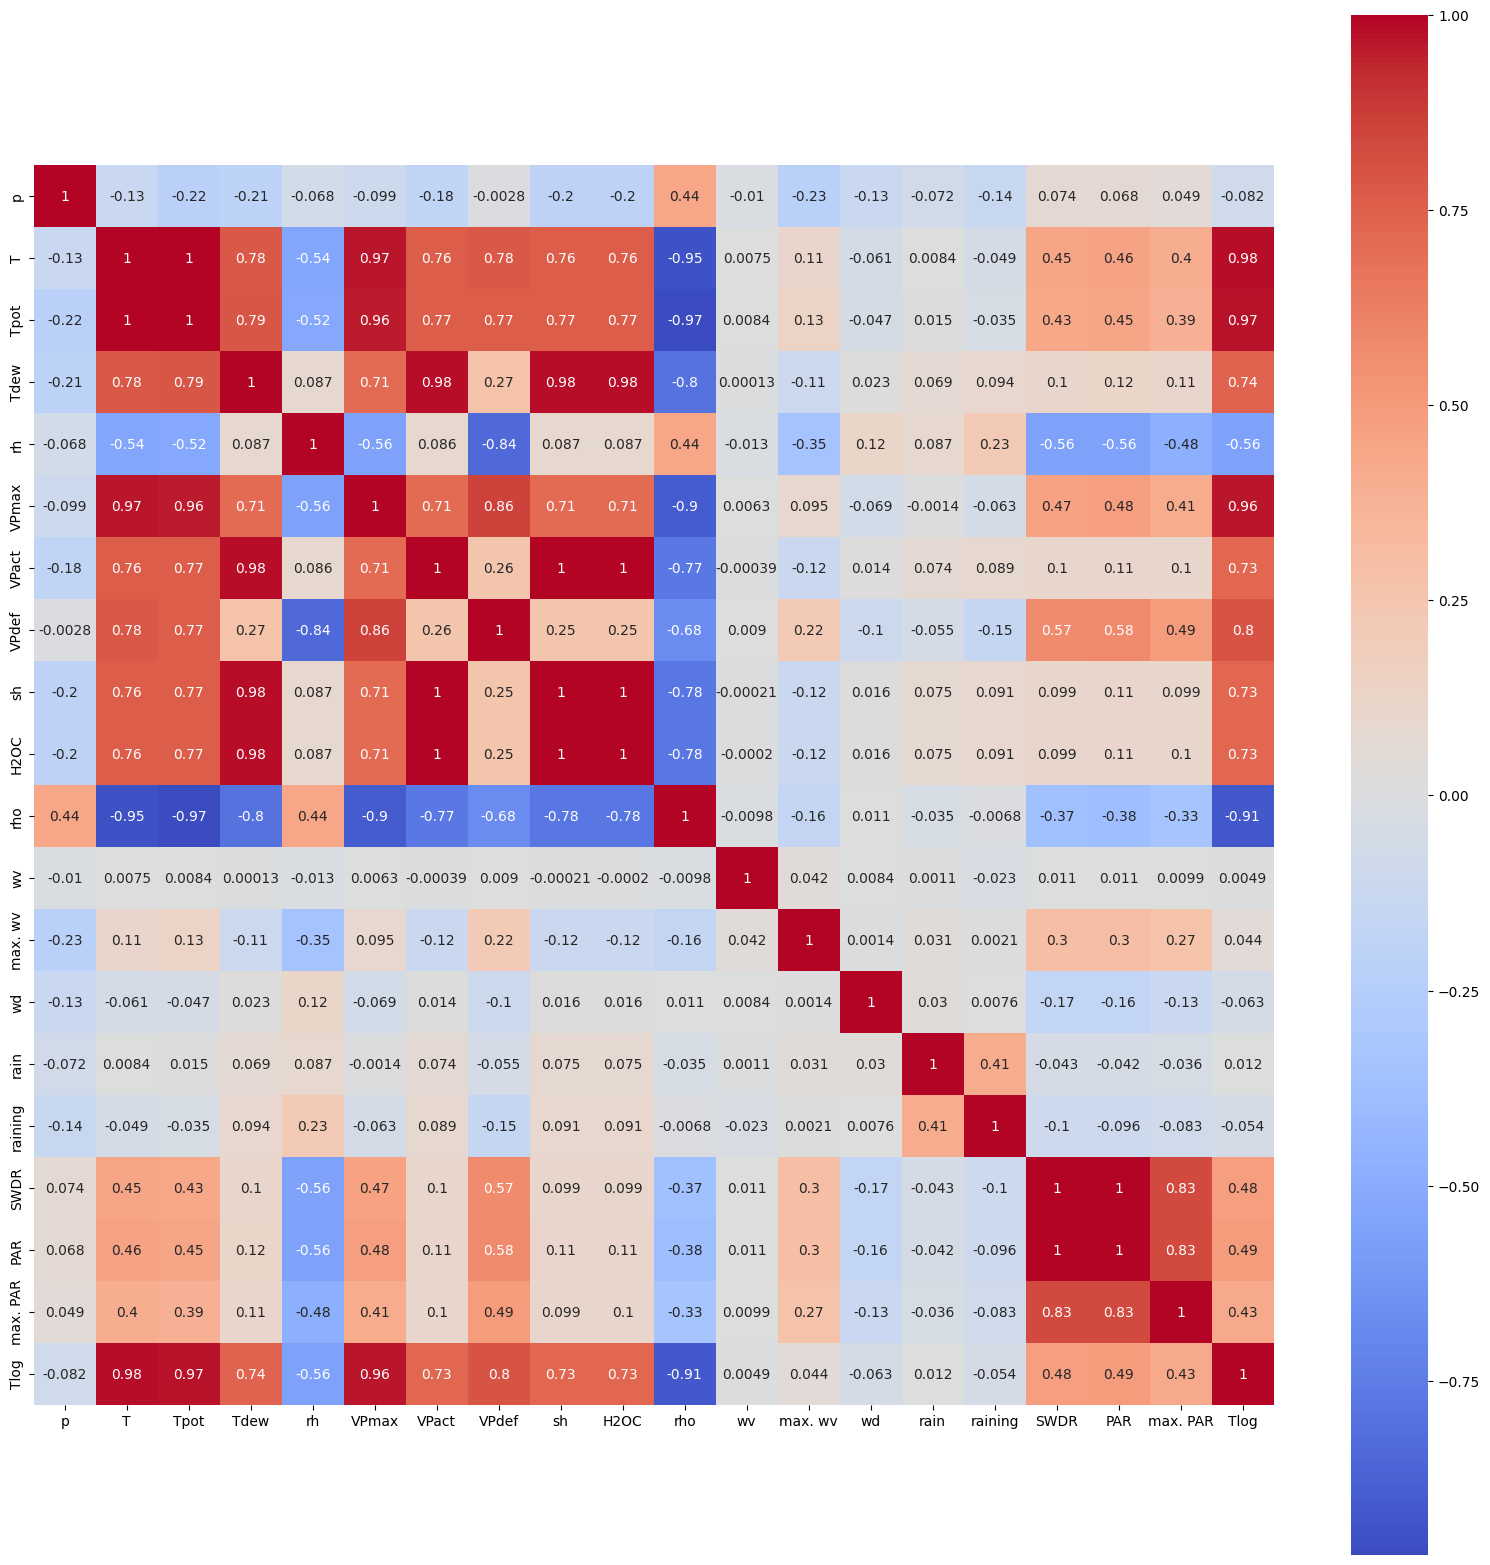

In [6]:
import seaborn as sns 

cor_matrix = df.corr()
cor = cor_matrix['T'].sort_values(ascending=False)
print("correlation of Temperature on another features: ",cor)
plt.figure(figsize=(20,20))
plt.imshow(cor_matrix)
sns.heatmap(cor_matrix,annot=True,cmap="coolwarm")
plt.show()

In [7]:
# taking important features
features = ['T', 'rh', 'p', 'wv', 'SWDR']
target = 'T'

In [ ]:
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

#Fit scalers
X_scaled = scaler_x.fit_transform(df[features])
y_scaled = scaler_y.fit_transform(df[[target]])

In [ ]:
def create_sequences(data_x, data_y, window_size,forecast_horizon):
    X, y = [], []
    for i in range(len(data_x) - window_size - forecast_horizon + 1):
        X.append(data_x[i : i + window_size])
        # Predict the point exactly 24 hours ahead(144 steps)
        y.append(data_y[i + window_size + forecast_horizon - 1]) 
    return np.array(X), np.array(y)

In [ ]:
#Data is every 10 mins. 
#24 hours = 6 * 24 = 144 steps
WINDOW_SIZE = 144     #Look at last 24 hours
FORECAST_HORIZON = 144   #Predict 24 hours into the future

X, y = create_sequences(X_scaled, y_scaled, WINDOW_SIZE, FORECAST_HORIZON)

In [ ]:
# 3.Train/Test Split
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print("Training Shape:", X_train.shape)

Training Shape: (41927, 144, 5)


In [ ]:
# 4.Build LSTM Model
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [ ]:
# 5.Train
history = model.fit(X_train, y_train, epochs=50,batch_size=32, validation_split=0.2, callbacks=[early_stop],verbose=1)

Epoch 1/50
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 72s 65ms/step - loss: 0.0096 - mae: 0.0743 - val_loss: 0.0058 - val_mae: 0.0581
Epoch 2/50
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 66s 63ms/step - loss: 0.0070 - mae: 0.0657 - val_loss: 0.0058 - val_mae: 0.0610
Epoch 3/50
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 74s 71ms/step - loss: 0.0067 - mae: 0.0638 - val_loss: 0.0051 - val_mae: 0.0540
Epoch 4/50
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 80s 76ms/step - loss: 0.0064 - mae: 0.0623 - val_loss: 0.0059 - val_mae: 0.0592
Epoch 5/50
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 78s 74ms/step - loss: 0.0061 - mae: 0.0608 - val_loss: 0.0067 - val_mae: 0.0618
Epoch 6/50
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 79s 75ms/step - loss: 0.0059 - mae: 0.0601 - val_loss: 0.0062 - val_mae: 0.0613
Epoch 7/50
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 75s 71ms/step - loss: 0.0056 - mae: 0.0586 - val_loss: 0.0090 - val_mae: 0.0709
Epoch 8/50
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 79s 75ms/step - loss: 0.0056 - mae: 0.0581 - val_loss: 0.0090 - val_mae: 0.0768


328/328 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step


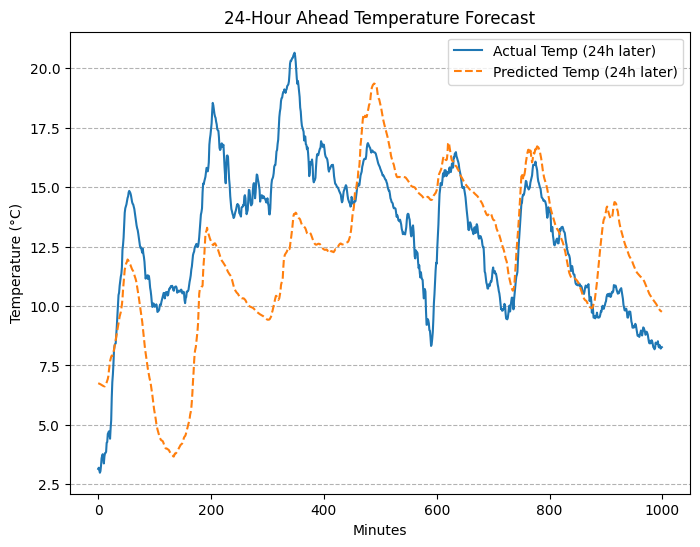

In [ ]:
# 6.Evaluate & Visualise
predictions_scaled = model.predict(X_test)
predictions = scaler_y.inverse_transform(predictions_scaled)
y_test_actual = scaler_y.inverse_transform(y_test)

# Plot a slice of the results
plt.figure(figsize=(8, 6))
plt.plot(y_test_actual[:1000], label='Actual Temp (24h later)')
plt.plot(predictions[:1000], label='Predicted Temp (24h later)', linestyle='--')
plt.xlabel("Minutes")
plt.ylabel("Temperature (°C)")
plt.grid(axis='y',linestyle='--',color='gray',alpha=0.6)
plt.legend()
plt.title("24-Hour Ahead Temperature Forecast")
plt.show()

In [15]:
# Get the last 24 hours of data from your dataframe
last_24h_data = X_scaled[-WINDOW_SIZE:] 
last_24h_data = last_24h_data.reshape(1, WINDOW_SIZE, len(features)) # Reshape to (1, 144, 5)

# Predict
prediction_scaled = model.predict(last_24h_data)
predicted_temp = scaler_y.inverse_transform(prediction_scaled)

print(f"Predicted Temperature 24 hours from now: {predicted_temp[0][0]:.2f}°C")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Predicted Temperature 24 hours from now: 4.12°C


In [ ]:
# import joblib

# # Save the Keras model
# model.save('weather_model.keras')

# # Save the scalers
# joblib.dump(scaler_x, 'scaler_x.pkl')
# joblib.dump(scaler_y, 'scaler_y.pkl')

In [18]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

mse = mean_squared_error(y_test_actual[:1000], predictions[:1000])
rmse = np.sqrt(mse) 

print(f"RMSE score: {rmse}")
mae = mean_absolute_error(y_test_actual, predictions)

print(f"Mean Absolute Error: {mae}")
r2 = r2_score(y_test_actual, predictions)

print(f"R-squared Score: {r2}")

RMSE score: 3.4186838764770617
Mean Absolute Error: 2.3876557773502256
R-squared Score: 0.6250775996347493
